In [112]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [113]:
# Загрузка датасета и проверка на пропуски
dataset = sklearn.datasets.fetch_california_housing(as_frame=True)
dataframe = dataset.frame
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [114]:
# Нормализация признака население
scaler = MinMaxScaler()
dataframe['Population_normalized'] = scaler.fit_transform(dataframe[['Population']])
print(dataframe[['Population', 'Population_normalized']].head())

   Population  Population_normalized
0       322.0               0.008941
1      2401.0               0.067210
2       496.0               0.013818
3       558.0               0.015555
4       565.0               0.015752


In [115]:
# Целевая переменная и признаки
y = dataframe['MedHouseVal']
X = dataframe.drop(['MedHouseVal', 'Population'], axis=1)

# Разбивка на обучающее и тестовое множества
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
# Функция для обучения модели и метрики score

def fit_model(X_train, y_train, X_test, y_test, model):

  model.fit(X_train, y_train)

  # Предсказание целевой переменной для тестового множества
  y_test_pred = model.predict(X_test)

  # Первые 5 предсказанных значений для тестового множества
  print('Первые 5 предсказанных значений:')
  print(y_test_pred[:5])

  # Первые 5 истинных значений для тестового множества
  print('\nПервые 5 истинных значений:')
  print(y_test.head())

  # Оценка точности модели на тестовом множестве с помощью score()
  score = model.score(X_test, y_test)
  print(f'Коэффициент детерминации (R-квадрат) на тестовом множестве: {score:.3f}')
  return model # Возвращаем обученную модель

In [117]:
# Линейная регрессия
line_model = fit_model(X_train, y_train, X_test, y_test, LinearRegression())

Первые 5 предсказанных значений:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]

Первые 5 истинных значений:
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
Name: MedHouseVal, dtype: float64
Коэффициент детерминации (R-квадрат) на тестовом множестве: 0.576


In [118]:
# Дерево решений
dt_model = fit_model(X_train, y_train, X_test, y_test, DecisionTreeRegressor(random_state=42))

Первые 5 предсказанных значений:
[0.414   1.203   5.00001 2.225   2.257  ]

Первые 5 истинных значений:
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
Name: MedHouseVal, dtype: float64
Коэффициент детерминации (R-квадрат) на тестовом множестве: 0.624


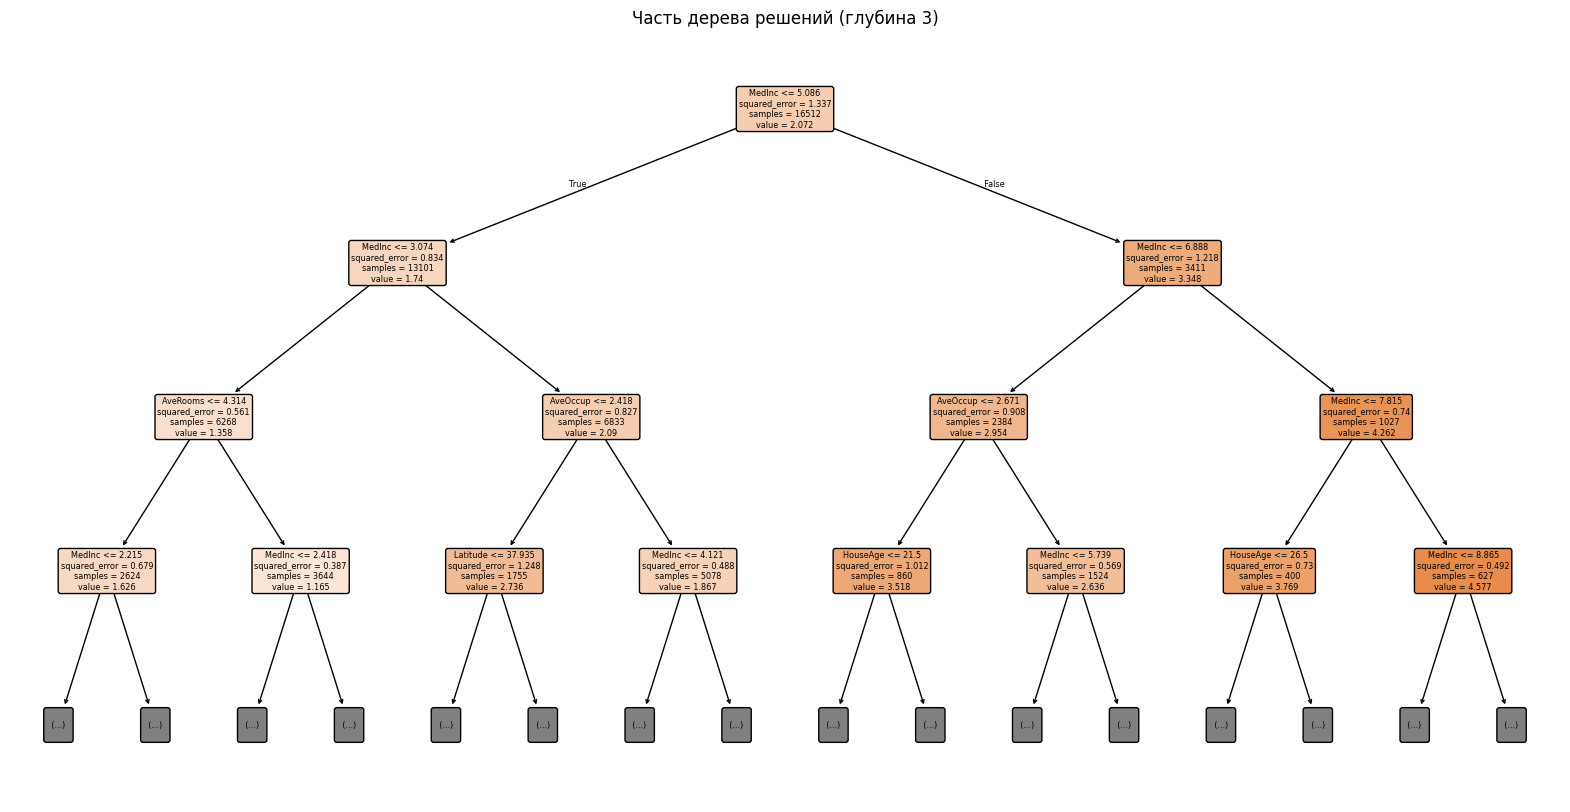

In [119]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          max_depth=3) # Ограничиваем глубину для читаемости
plt.title("Часть дерева решений (глубина 3)")
plt.show()

### Оптимизация `max_depth` и `min_samples_leaf` для `DecisionTreeRegressor`

Мы будем перебирать различные значения для `max_depth` и `min_samples_leaf` и отслеживать метрику R-квадрат, чтобы найти оптимальные параметры. Затем визуализируем результаты.

In [ ]:
# Диапазон значений для max_depth и min_samples_leaf
max_depth_values = range(1, 21)
min_samples_leaf_values = [1, 5, 10, 20, 50, 100]

r2_scores = []

for depth in max_depth_values:
    for min_leaf in min_samples_leaf_values:
        dt_model_tuned = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=min_leaf, random_state=42)
        dt_model_tuned.fit(X_train, y_train)
        score = dt_model_tuned.score(X_test, y_test)
        r2_scores.append({'max_depth': depth, 'min_samples_leaf': min_leaf, 'r2_score': score})

r2_df = pd.DataFrame(r2_scores)

# Лучшие параметры
best_params = r2_df.loc[r2_df['r2_score'].idxmax()]
print(f"Лучший R-квадрат: {best_params['r2_score']:.3f}")
print(f"Оптимальный max_depth: {best_params['max_depth']}")
print(f"Оптимальный min_samples_leaf: {best_params['min_samples_leaf']}")

### Выводы по проделанной работе

**Сравнение точности двух моделей**
*   **Линейная регрессия:** Коэффициент детерминации (R-квадрат) на тестовой выборке составил **0.576**.
*   **Дерево решений (DecisionTreeRegressor):** Изначально R-квадрат был **0.624**. После оптимизации гиперпараметров (`max_depth` и `min_samples_leaf`), лучший R-квадрат составил **0.727** при `max_depth=17` и `min_samples_leaf=20`.

Таким образом, **модель дерева решений, особенно после настройки гиперпараметров, показала значительно лучшую производительность** Это означает, что `DecisionTreeRegressor` смогла лучше уловить нелинейные зависимости в данных.

**Мнение о предпочтительности использования моделей, их плюсы и минусы**

**1. Линейная регрессия**

*   **Для каких задач предпочтительнее:**
    *   Когда предполагается линейная зависимость между признаками и целевой переменной.
    *   Когда нужна простая, быстрая и легко интерпретируемая модель.
    *   Для задач, где важна скорость обучения и предсказания.
*   **Плюсы:**
    *   **Простота и скорость:** Легко реализуется и быстро обучается даже на больших объемах данных.
    *   **Интерпретируемость:** Коэффициенты модели показывают прямую зависимость целевой переменной от каждого признака, что позволяет легко понять вклад каждого фактора.
    *   **Отсутствие переобучения:** Менее склонна к переобучению по сравнению с более сложными моделями, если базовая предпосылка о линейности верна.
*   **Минусы:**
    *   **Предполагает линейность:** Плохо работает, если истинная зависимость между переменными нелинейна, что часто бывает в реальных данных.
    *   **Чувствительность к выбросам:** Выбросы могут сильно искажать коэффициенты и, следовательно, предсказания модели.

**2. Дерево решений (DecisionTreeRegressor)**

*   **Для каких задач предпочтительнее:**
    *   Когда зависимости между признаками и целевой переменной сложны и нелинейны.
    *   Когда важна возможность визуализации процесса принятия решений (для неглубоких деревьев).
    *   Для задач, где нужно понять, какие признаки являются наиболее важными и как они взаимодействуют.
*   **Плюсы:**
    *   **Моделирование нелинейных зависимостей:** Способно улавливать сложные нелинейные отношения в данных без предварительного преобразования признаков.
    *   **Работа с различными типами данных:** Может обрабатывать как числовые, так и категориальные признаки.
    *   **Интерпретируемость (для неглубоких деревьев):** Для деревьев с небольшой глубиной логику принятия решений легко понять и визуализировать.
    *   **Устойчивость к масштабированию признаков:** Не требует масштабирования или нормализации признаков, в отличие от линейной регрессии.
*   **Минусы:**
    *   **Склонность к переобучению:** Очень глубокие деревья могут легко переобучаться на обучающих данных, запоминая шум, что приводит к плохой обобщающей способности. Настройка гиперпараметров, таких как `max_depth` и `min_samples_leaf`, критична.
    *   **Неустойчивость (высокая дисперсия):** Небольшие изменения в обучающих данных могут привести к значительному изменению структуры дерева, делая его менее стабильным.
    *   **Ограниченная обобщающая способность (экстраполяция):** Деревья решений плохо экстраполируют за пределы диапазона обучающих данных.